In [1]:
!rm -rf IFIC-SummerSchool-2025
!git clone https://github.com/M0V1/IFIC-SummerSchool-2025.git
!pip install  numpy pandas uproot matplotlib mplhep awkward  pandas xgboost  scikit-learn

Cloning into 'IFIC-SummerSchool-2025'...
remote: Enumerating objects: 158, done.
remote: Counting objects: 100% (158/158), done.
remote: Compressing objects: 100% (155/155), done.
remote: Total 158 (delta 66), reused 4 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (158/158), 81.35 MiB | 18.00 MiB/s, done.
Resolving deltas: 100% (66/66), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 382.8/382.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 886.8/886.8 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 638.8/638.8 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 79.2 MB/s eta 0:00:00


In [2]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import mplhep as hep
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from concurrent.futures import ProcessPoolExecutor, as_completed
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb
# Integrated luminosity in inverse picobarns
lumi = 36000.

In [3]:
files = [
    "IFIC-SummerSchool-2025/ODEO_FEB2025_v0_2J2LMET30_mc_700903.Sh_2214_Ztt_maxHTpTV2_Mll10_40_CVetoBVeto.2J2LMET30.root",   #bkg
    "IFIC-SummerSchool-2025/ODEO_FEB2025_v0_2J2LMET30_mc_410471.PhPy8EG_A14_ttbar_hdamp258p75_allhad.2J2LMET30.root",     #bkg
    "IFIC-SummerSchool-2025/ODEO_FEB2025_v0_2J2LMET30_mc_345121.PowhegPy8EG_NNLOPS_nnlo_30_ggH125_tautaulm15hp20.2J2LMET30.root", #signal
    "IFIC-SummerSchool-2025/ODEO_FEB2025_v0_2J2LMET30_mc_345122.PowhegPy8EG_NNLOPS_nnlo_30_ggH125_tautaulp15hm20.2J2LMET30.root",#signal
    "IFIC-SummerSchool-2025/ODEO_FEB2025_v0_2J2LMET30_mc_346343.PhPy8EG_A14NNPDF23_NNPDF30ME_ttH125_allhad.2J2LMET30.root",
    "IFIC-SummerSchool-2025/ODEO_FEB2025_v0_2J2LMET30_mc_700792.Sh_2214_Ztautau_maxHTpTV2_BFilter.2J2LMET30.root",     #bkg
    "IFIC-SummerSchool-2025/ODEO_FEB2025_v0_2J2LMET30_data15_periodF.2J2LMET30.root",  #data
    "IFIC-SummerSchool-2025/ODEO_FEB2025_v0_2J2LMET30_mc_346344.PhPy8EG_A14NNPDF23_NNPDF30ME_ttH125_semilep.2J2LMET30.root", #signal
    "IFIC-SummerSchool-2025/ODEO_FEB2025_v0_2J2LMET30_data15_periodH.2J2LMET30.root",  #data
    "IFIC-SummerSchool-2025/ODEO_FEB2025_v0_2J2LMET30_mc_700902.Sh_2214_Ztt_maxHTpTV2_Mll10_40_CFilterBVeto.2J2LMET30.root", #bkg
    "IFIC-SummerSchool-2025/ODEO_FEB2025_v0_2J2LMET30_mc_345120.PowhegPy8EG_NNLOPS_nnlo_30_ggH125_tautaul13l7.2J2LMET30.root",
    "IFIC-SummerSchool-2025/ODEO_FEB2025_v0_2J2LMET30_mc_700901.Sh_2214_Ztt_maxHTpTV2_Mll10_40_BFilter.2J2LMET30.root" #bkg
]

tree_name = "analysis"

In [10]:
signal_keywords = ["ggH125", "ttH125"]
bkg_keywords = ["Ztt", "ttbar", "Ztautau"]
data_keywords = ["data15"]

def classify_sample(filename):
    if any(key in filename for key in signal_keywords):
        return "signal"
    elif any(key in filename for key in data_keywords):
        return "data"
    elif any(key in filename for key in bkg_keywords):
        return "background"
    else:
        return "unknown"

features = [
    "tau_pt", "tau_eta", "tau_phi",
    "met", "met_phi",
    "lep_pt", "lep_eta", "lep_phi",
    "jet_e", "jet_pt", "jet_eta", "jet_phi", "jet_btag_quantile",
    "tau_e", "tau_charge",
]


def load_sample(path, label):
    try:
        with uproot.open(path)[tree_name] as tree:
            arrays = tree.arrays(features, library="ak")
            df = ak.to_dataframe(arrays)
            df["label"] = label
        return df
    except Exception as e:
        print(f"Erreur pour {path}: {e}")
        return pd.DataFrame()

all_data = []

with ProcessPoolExecutor() as executor:
    futures = []
    for path in files:
        sample_type = classify_sample(path)
        if sample_type == "unknown": continue
        label = 1 if sample_type == "signal" else (0 if sample_type == "background" else None)
        if label is not None:
            futures.append(executor.submit(load_sample, path, label))

    for future in as_completed(futures):
        df = future.result()
        if not df.empty:
            all_data.append(df)


df_total = pd.concat(all_data, ignore_index=True)
print("Total d'événements :", len(df_total))

Total d'événements : 30785


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:45:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


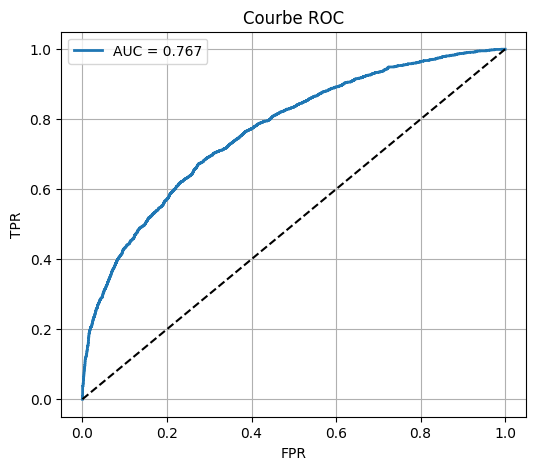

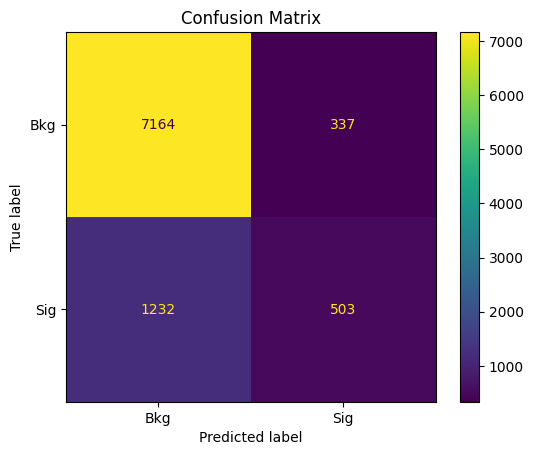

In [11]:
X = df_total[features]
y = df_total["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)


y_score = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Courbe ROC")
plt.legend()
plt.grid(True)
plt.show()


ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Bkg", "Sig"])
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()


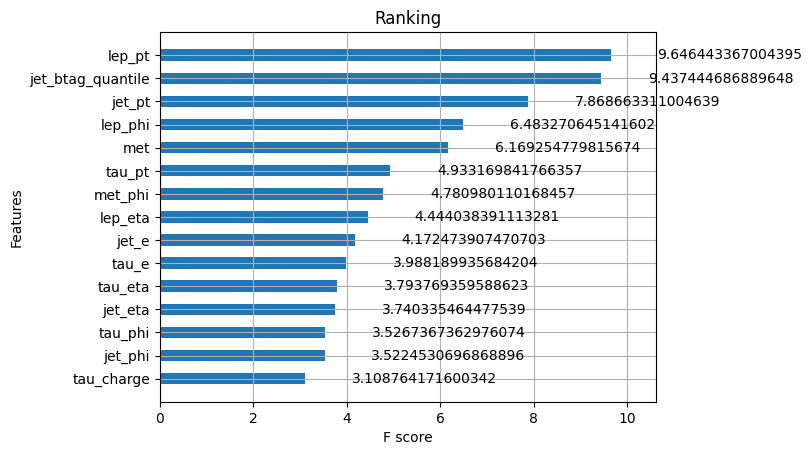

In [12]:
xgb.plot_importance(model, importance_type="gain", height=0.5)
plt.title("Ranking")
plt.grid(True)
plt.show()


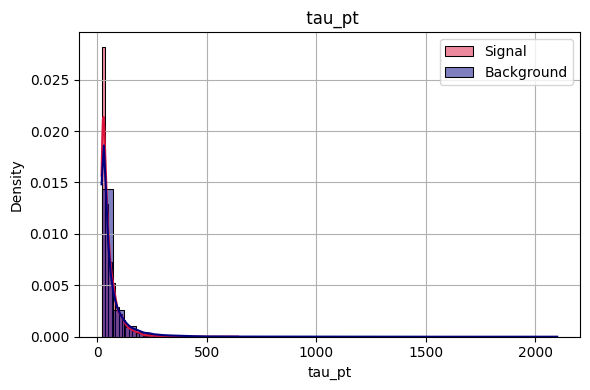

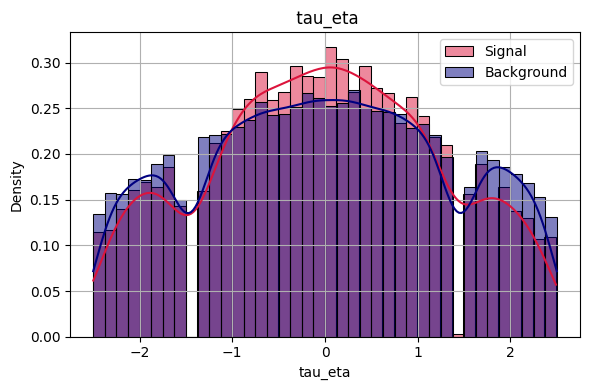

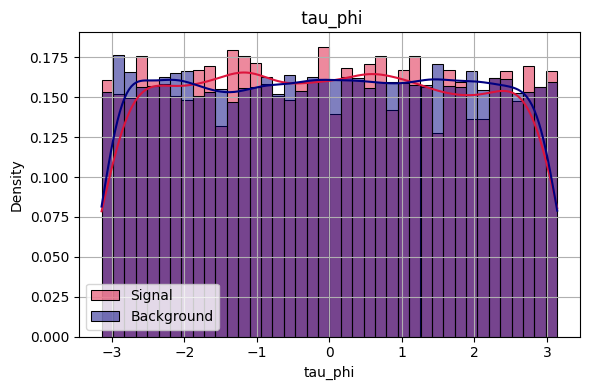

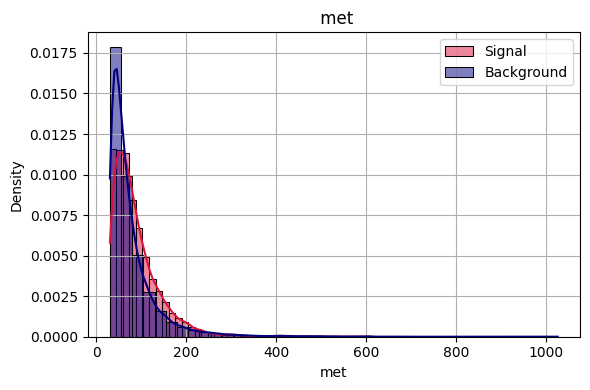

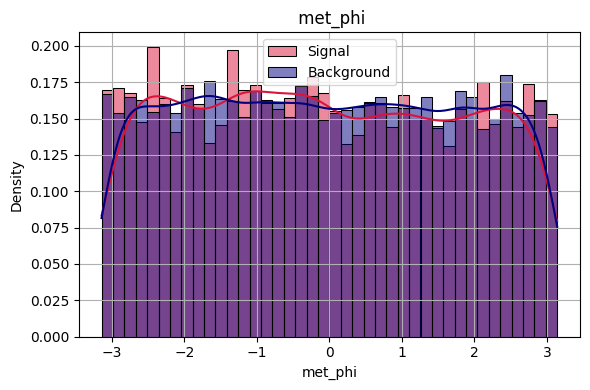

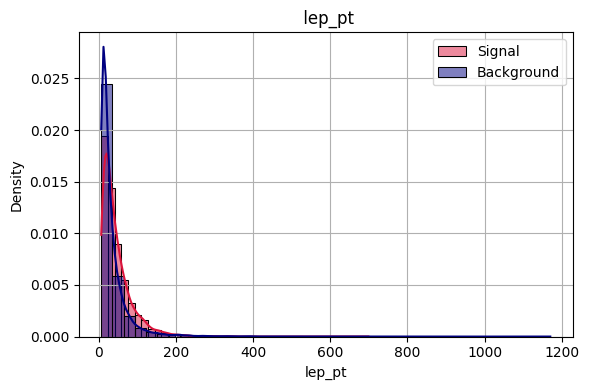

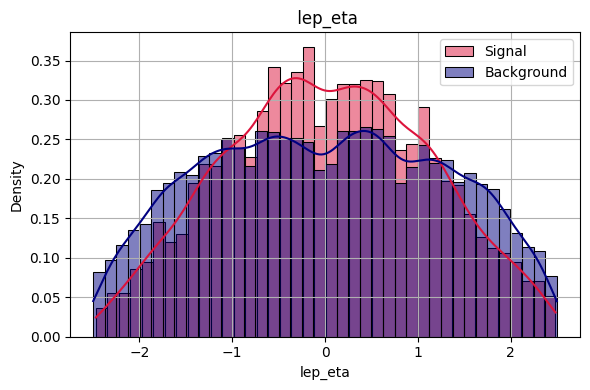

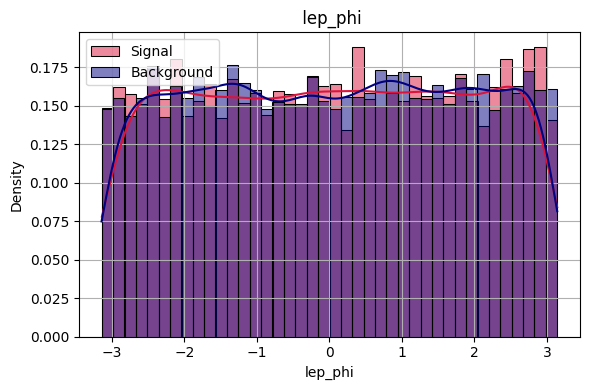

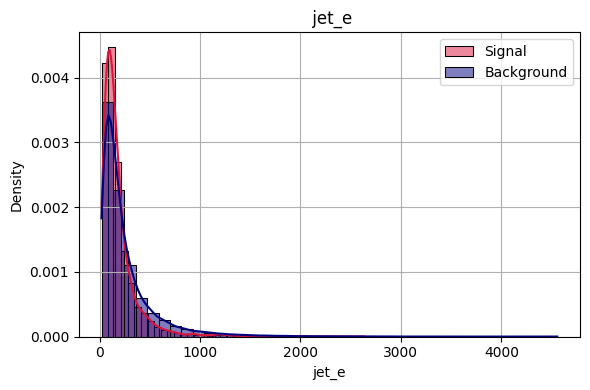

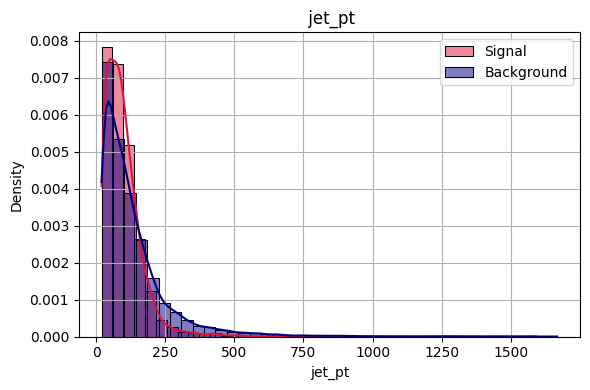

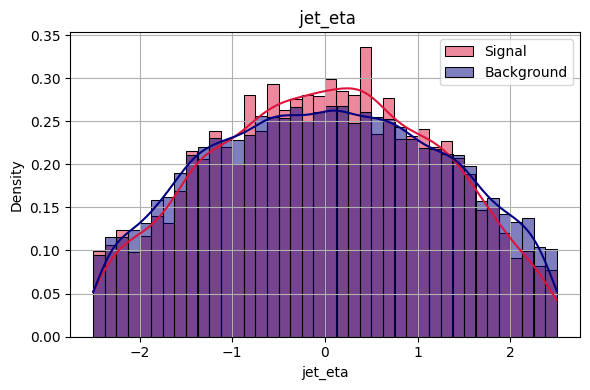

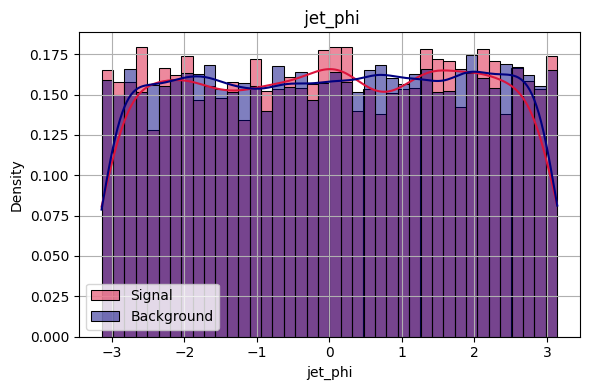

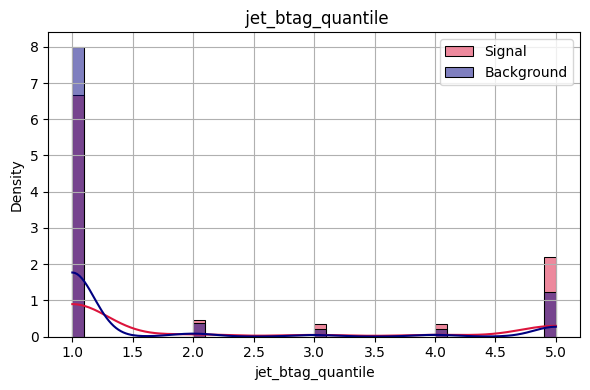

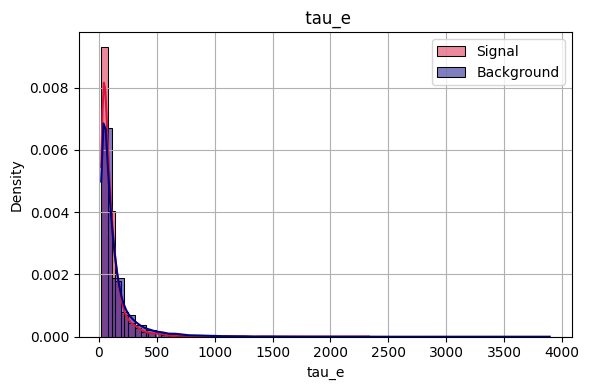

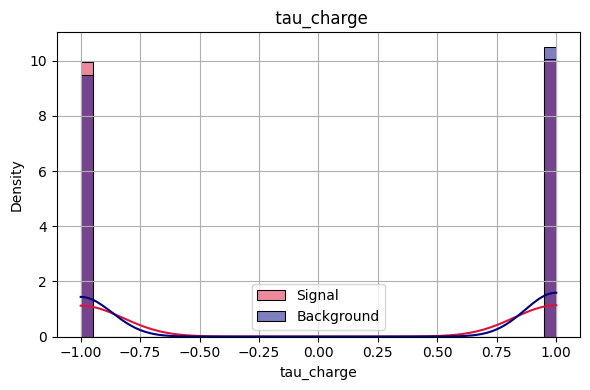

In [14]:
import seaborn as sns

def plot_feature_distributions(df, features, label_col="label", bins=40):
    for var in features:
        plt.figure(figsize=(6, 4))
        sns.histplot(df[df[label_col] == 1][var], color="crimson", label="Signal", stat="density", bins=bins, kde=True)
        sns.histplot(df[df[label_col] == 0][var], color="navy", label="Background", stat="density", bins=bins, kde=True)
        plt.title(f" {var}")
        plt.xlabel(var)
        plt.ylabel("Density")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

plot_feature_distributions(df_total, features)